# Plant Disease Detection with MobileNet 

### Dataset Used: [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/data)

## 1. Import required libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pathlib
import numpy as np
import random
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import os
import mlflow
from mlflow import MlflowClient

In [4]:
from helper_functions import show_images, plot_curves, make_predictions, compare_historys

In [5]:
client = MlflowClient(tracking_uri="http://127.0.0.1:5000")

# Provide experiment description and tags
experiment_description = (
    "This is the plant disease detection project. "
    "This experiment contains the implementation of plant disease detection using MobileNetV2."
)

experiment_tags = {
    "project_name": "plant_disease_detection",
    "mlflow.note.content": experiment_description,
}

# Create an experiment
client.create_experiment(name="Plant_Disease_Detection", tags=experiment_tags)

'621861785685652756'

## 2. Data exploration

In [6]:
# Define root path
root_dir = "New Plant Diseases Dataset(Augmented)"

# Define paths to train, test and validation set
train_dir = os.path.join(root_dir, 'train/')
val_dir = os.path.join(root_dir, 'valid/')
test_dir = os.path.join(root_dir, 'test/')

In [7]:
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirectories
print(class_names)

['Apple___Apple_scab' 'Apple___Black_rot' 'Apple___Cedar_apple_rust'
 'Apple___healthy' 'Blueberry___healthy'
 'Cherry_(including_sour)___Powdery_mildew'
 'Cherry_(including_sour)___healthy'
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
 'Corn_(maize)___Common_rust_' 'Corn_(maize)___Northern_Leaf_Blight'
 'Corn_(maize)___healthy' 'Grape___Black_rot'
 'Grape___Esca_(Black_Measles)'
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)' 'Grape___healthy'
 'Orange___Haunglongbing_(Citrus_greening)' 'Peach___Bacterial_spot'
 'Peach___healthy' 'Pepper,_bell___Bacterial_spot'
 'Pepper,_bell___healthy' 'Potato___Early_blight' 'Potato___Late_blight'
 'Potato___healthy' 'Raspberry___healthy' 'Soybean___healthy'
 'Squash___Powdery_mildew' 'Strawberry___Leaf_scorch'
 'Strawberry___healthy' 'Tomato___Bacterial_spot' 'Tomato___Early_blight'
 'Tomato___Late_blight' 'Tomato___Leaf_Mold' 'Tomato___Septoria_leaf_spot'
 'Tomato___Spider_mites Two-spotted_spider_mite' 'Tomato___Target_Spot'
 'Tomato___Tom

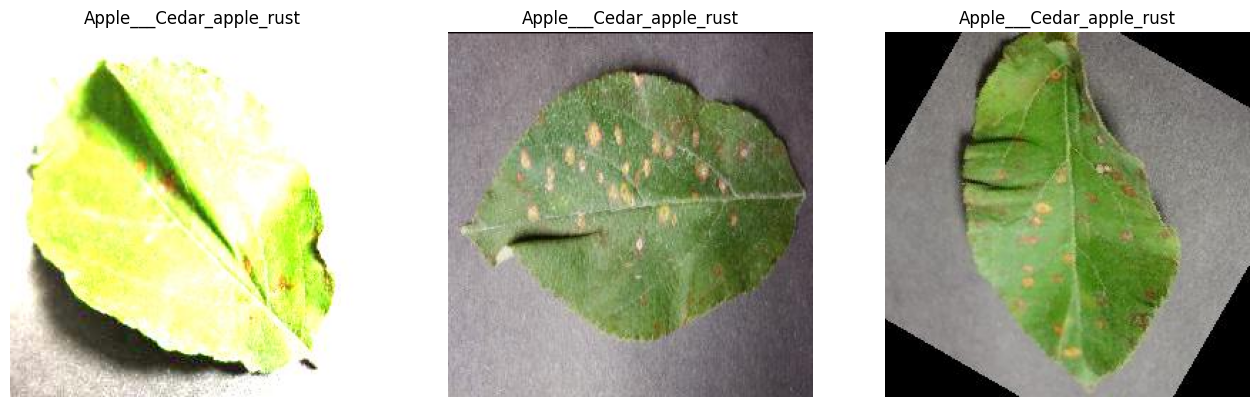

In [10]:
class_name = "Apple___Cedar_apple_rust"
show_images(train_dir, class_name)

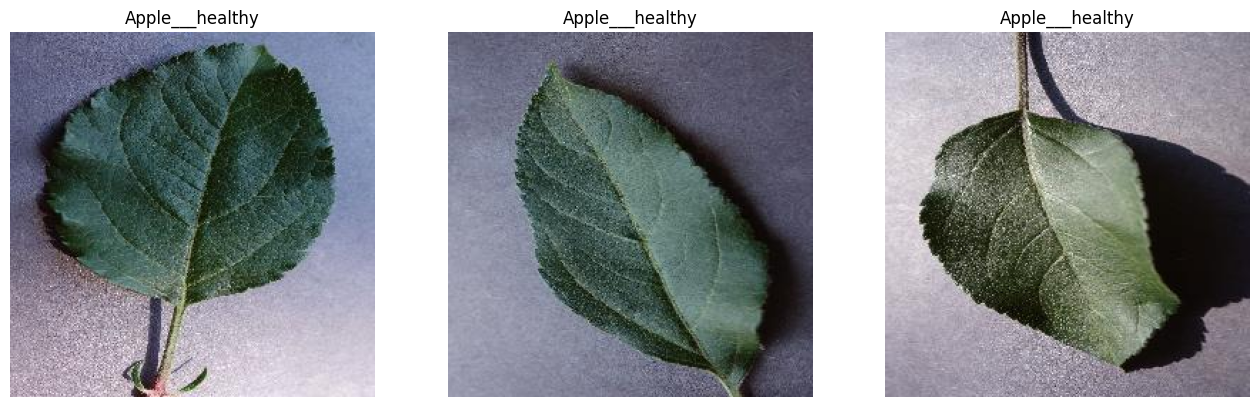

In [11]:
class_name = "Apple___healthy"
show_images(train_dir, class_name)

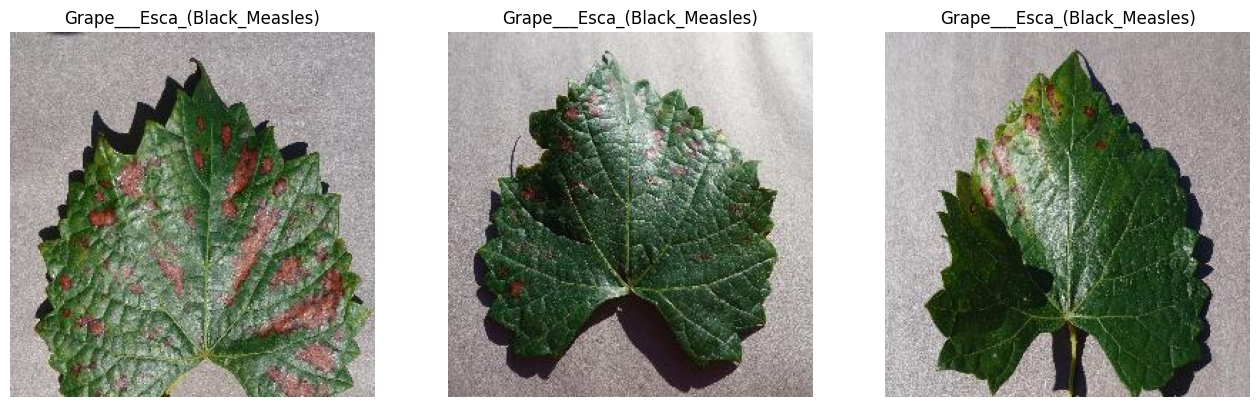

In [12]:
class_name = "Grape___Esca_(Black_Measles)"
show_images(train_dir, class_name)

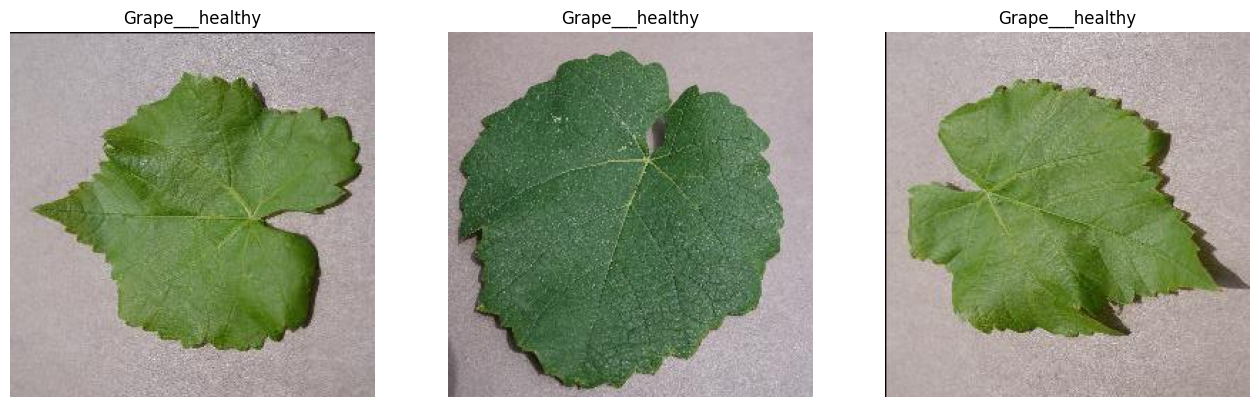

In [13]:
class_name = "Grape___healthy"
show_images(train_dir, class_name)

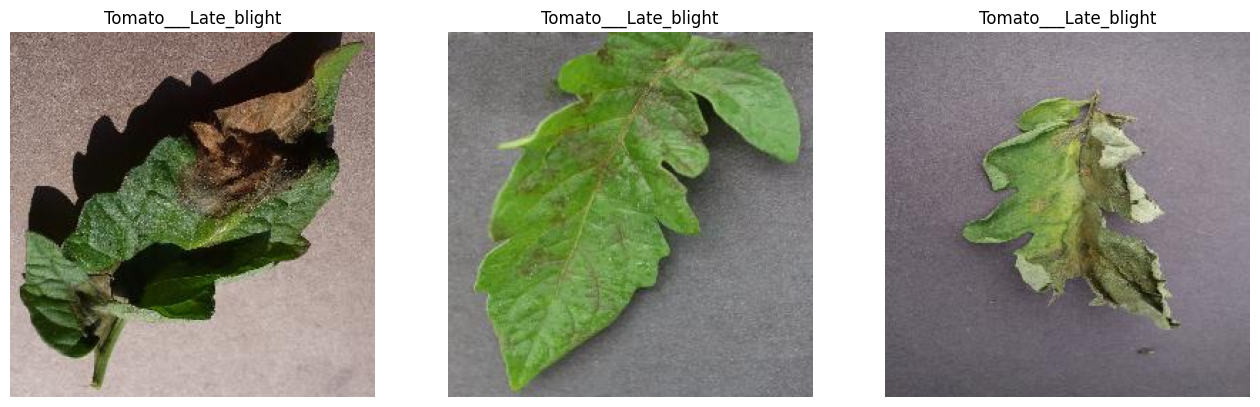

In [15]:
class_name = "Tomato___Late_blight"
show_images(train_dir, class_name)

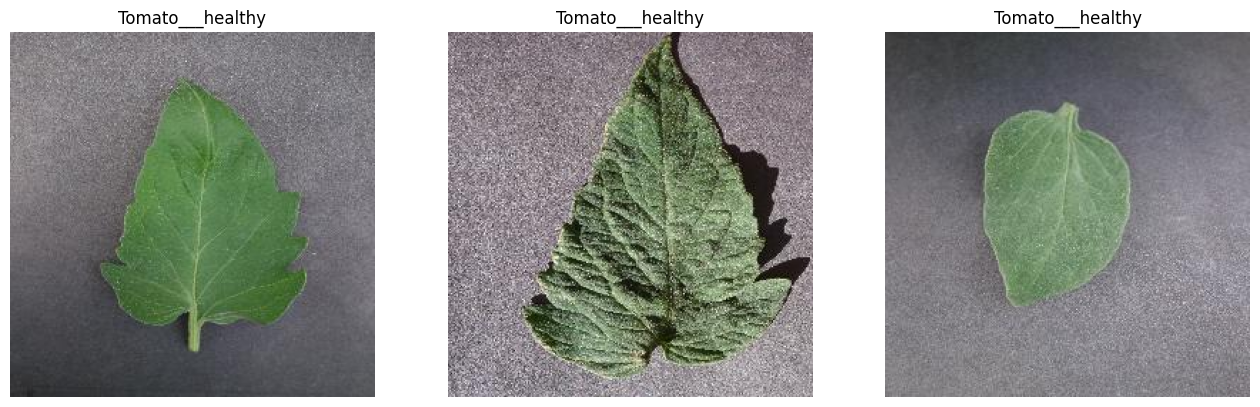

In [16]:
class_name = "Tomato___healthy"
show_images(train_dir, class_name)

## 3. Data Preprocessing

In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode="categorical", 
                                                                 image_size=IMG_SIZE
                                                                )

val_data = tf.keras.preprocessing.image_dataset_from_directory(val_dir, 
                                                                label_mode="categorical", 
                                                                image_size=IMG_SIZE, 
                                                                shuffle=False
                                                              )

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


## 4. Transfer Learning (Feature Extraction) with MobileNetV2

### 4.1. Model Architecture Selection

In [19]:
# Apply rescaling
data_scaling = Sequential([
  layers.Rescaling(1./155),
], name ="rescaling_layer")

In [20]:
# Setup the base model and freeze its layers
base_model = tf.keras.applications.MobileNetV2(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name ="input_layer")
x = data_scaling(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
outputs = layers.Dense(len(train_data.class_names), activation="softmax", name="output_layer")(x)
mobv2_model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_Transfer_Learning_Model")

In [21]:
# Check the layers in base model
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


In [22]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
mobv2_model.summary()

Model: "MobileNetV2_Transfer_Learning_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_layer (Sequential)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.2. Model Training

In [24]:
# Use the fluent API to set the tracking uri and the active experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

In [25]:
# Sets the current active experiment to the "Plant_Disease_Detection" experiment and returns the Experiment metadata
mobilenetv2_feature_extraction = mlflow.set_experiment("Plant_Disease_Detection")

# Define a run name for this iteration of training.
# If this is not set, a unique name will be auto-generated for your run.
run_name = "MobilenetV2_Transfer_Learning_Run"

In [26]:
mlflow.tensorflow.autolog()

In [27]:
with mlflow.start_run(run_name=run_name) as run:
    # Compile the model
    mobv2_model.compile(loss = "categorical_crossentropy", 
                        optimizer = Adam(), 
                        metrics = ["accuracy"]
                       )
    
    # Fit the model
    mobv2_model_history = mobv2_model.fit(train_data, 
                                          epochs = 10, 
                                          validation_data = val_data
                                         )

2025-10-28 22:59:52.681261: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-28 22:59:58.994617: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/10


2025-10-28 23:00:01.131769: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4400003160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-28 23:00:01.131799: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-10-28 23:00:01.185534: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-28 23:00:01.596867: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-28 23:00:01.646093: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 23:00:02.

2194/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8289 - loss: 0.6899

2025-10-28 23:00:57.015515: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-28 23:00:57.102860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9889 - loss: 0.0370 - val_accuracy: 0.9649 - val_loss: 0.1051
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9901 - loss: 0.0337 - val_accuracy: 0.9639 - val_loss: 0.1131


2025-10-28 23:09:32.138956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-28 23:09:32.225744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


2025/10/28 23:09:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run MobilenetV2_Transfer_Learning_Run at: http://127.0.0.1:5000/#/experiments/621861785685652756/runs/276cec96721240bc87d57cb51310f5f8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/621861785685652756


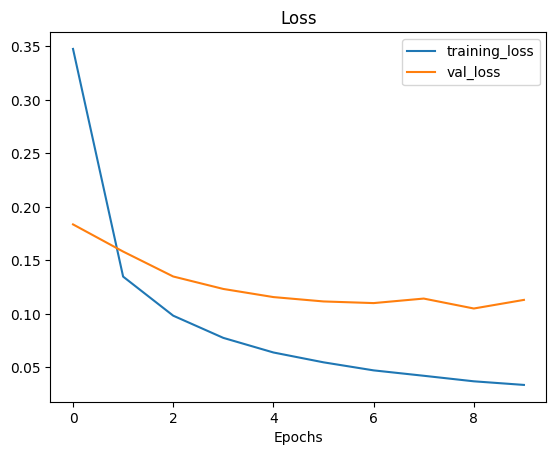

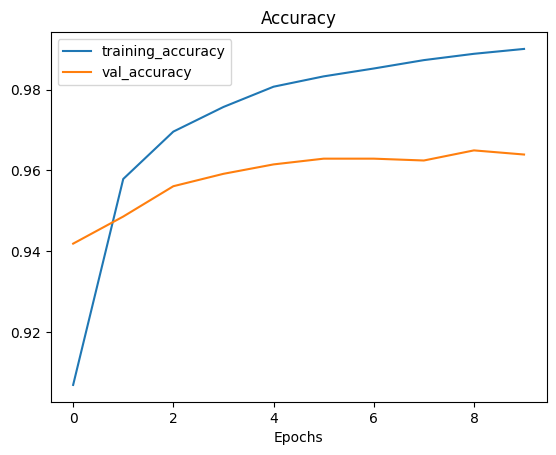

In [28]:
# Plot loss curves
plot_curves(mobv2_model_history)

### 4.3. Model Evaluation

In [30]:
# Make predictions on the validation set
predictions = mobv2_model.predict(val_data)

# Convert predictions from probabilities to class labels
predicted_classes = predictions.argmax(axis=1)

# Get True Labels
# Initialize an empty list to store the true labels
true_labels_list = []

# Iterate over the val_data dataset and collect the labels (y)
for images, labels in val_data:
    # 'labels' is a batch of one-hot encoded labels.
    # We append the batch to our list.
    true_labels_list.append(labels.numpy())

# Concatenate all label batches into a single numpy array
true_labels_categorical = np.concatenate(true_labels_list, axis=0)

# Convert the one-hot encoded labels to integer class indices
true_classes = np.argmax(true_labels_categorical, axis=1)

# Get class labels
class_labels = val_data.class_names

# Generate classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

print(report)

550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.97      0.98       504
                                 Apple___Black_rot       0.99      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.99      0.99       440
                                   Apple___healthy       1.00      0.99      0.99       502
                               Blueberry___healthy       1.00      0.99      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.94      0.92       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northe

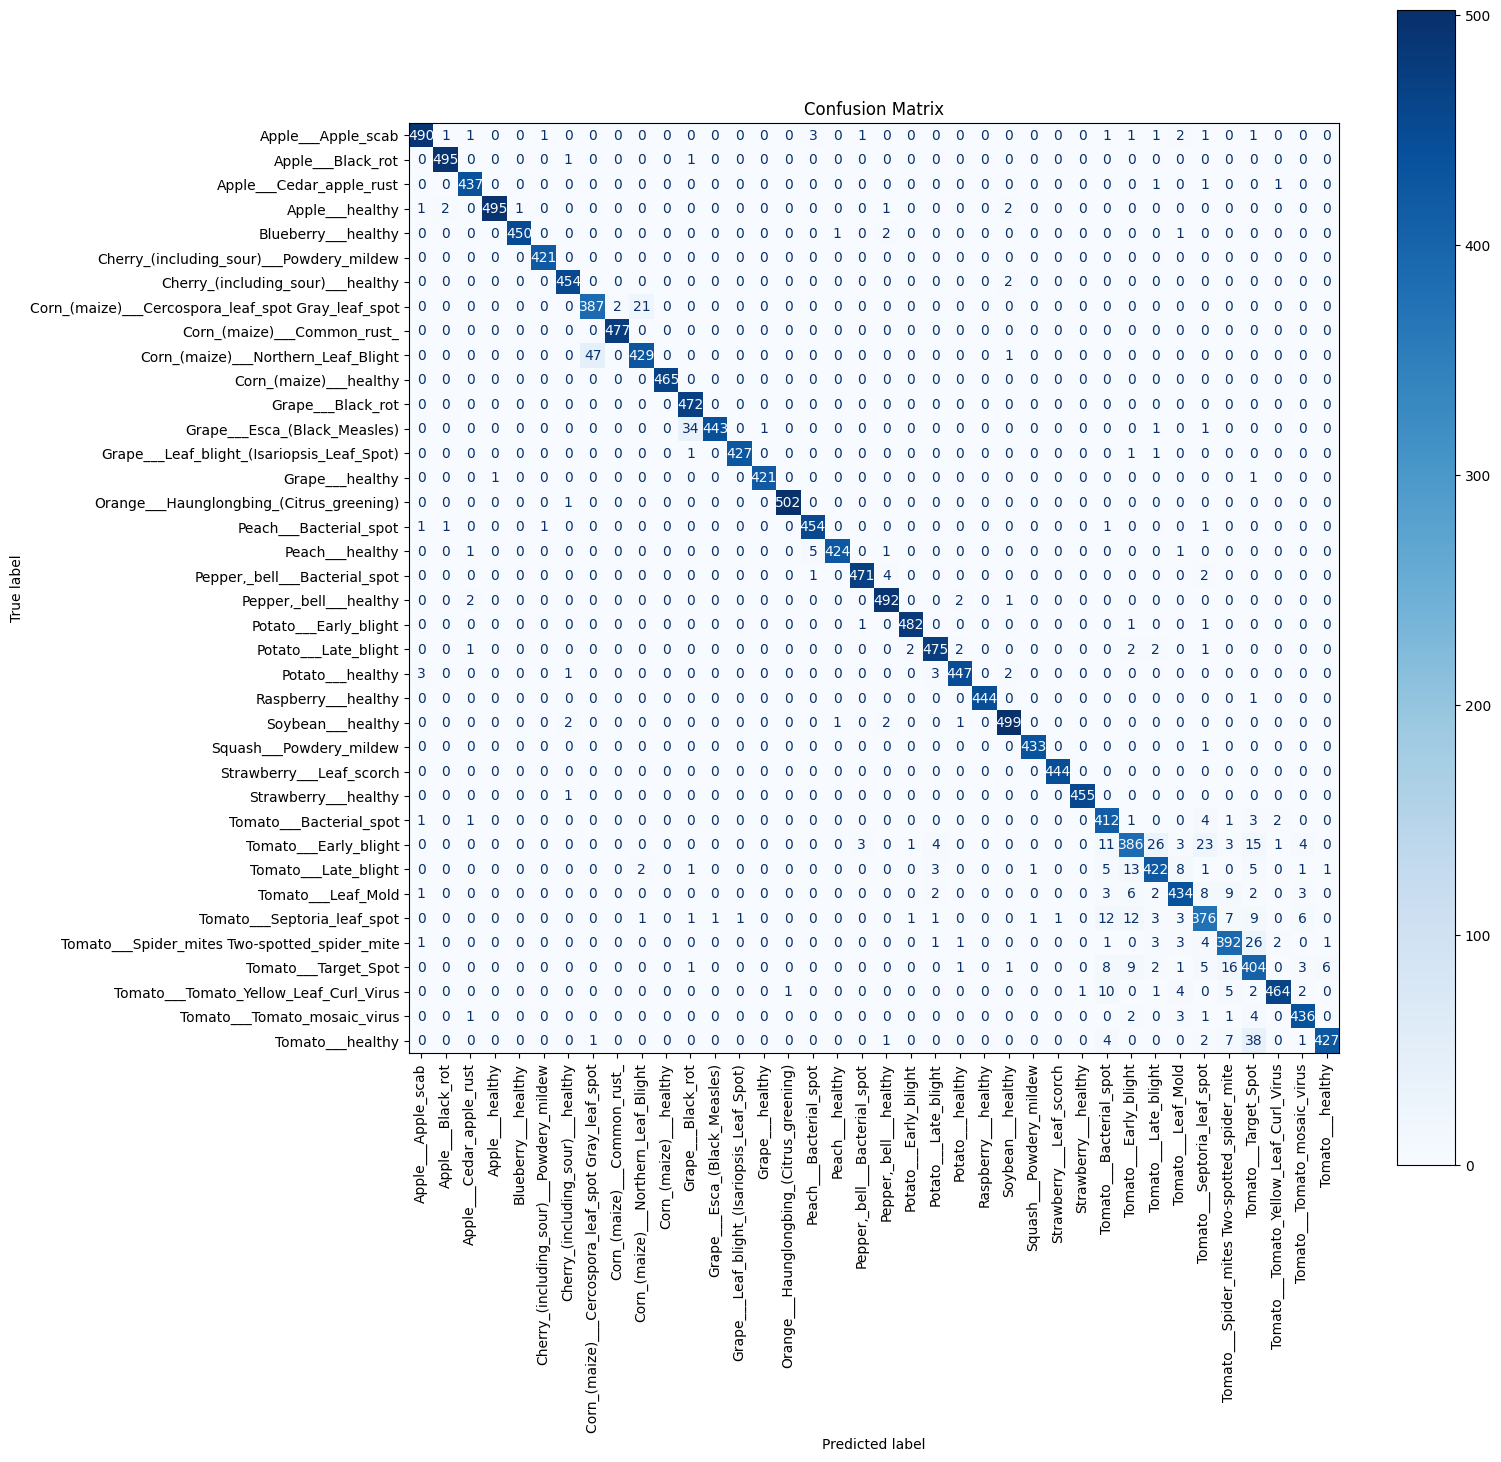

In [31]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, 
                              display_labels = class_labels
                             )

fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(cmap = "Blues", ax=ax)

plt.xticks(rotation = 90)
plt.title('Confusion Matrix')
plt.show()

## 5. Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


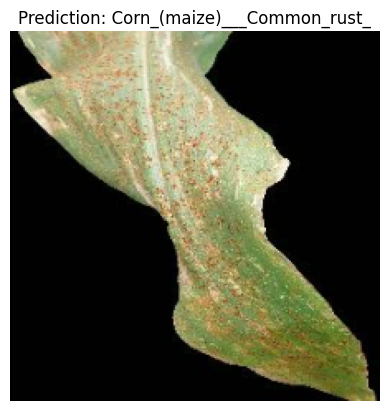

In [33]:
image_path = test_dir + "CornCommonRust3.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


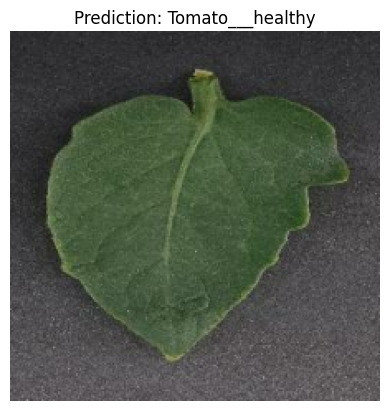

In [35]:
image_path = test_dir + "TomatoHealthy2.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


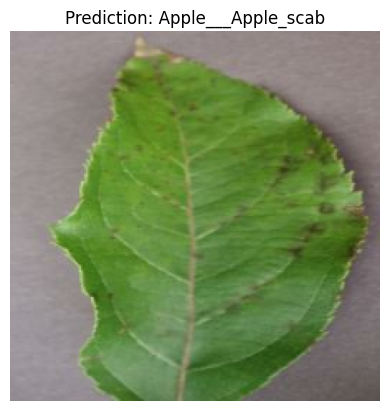

In [36]:
image_path = test_dir + "AppleScab1.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


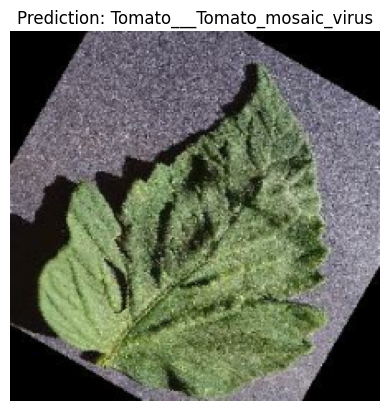

In [38]:
image_path = test_dir + "TomatoHealthy3.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

## 6. Save Feature Extraction Model

In [39]:
mobv2_model.save("MobileNetV2_Transfer_Learning_Model.keras")

## 7. Fine-Tuning the MobileNetV2

In [40]:
mobv2_model.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=rescaling_layer, built=True>,
 <Functional name=mobilenetv2_1.00_224, built=True>,
 <GlobalAveragePooling2D name=global_avg_pool, built=True>,
 <Dense name=output_layer, built=True>]

In [41]:
# Check trainable layers
for layer in mobv2_model.layers:
    print(layer, layer.trainable)

<InputLayer name=input_layer, built=True> True
<Sequential name=rescaling_layer, built=True> True
<Functional name=mobilenetv2_1.00_224, built=True> False
<GlobalAveragePooling2D name=global_avg_pool, built=True> True
<Dense name=output_layer, built=True> True


In [43]:
# check trainable layers in base_model .i.e. MobilenetV2
for i, layer in enumerate(mobv2_model.layers[2].layers):
    print(i, layer.name, layer.trainable)

0 input_layer False
1 Conv1 False
2 bn_Conv1 False
3 Conv1_relu False
4 expanded_conv_depthwise False
5 expanded_conv_depthwise_BN False
6 expanded_conv_depthwise_relu False
7 expanded_conv_project False
8 expanded_conv_project_BN False
9 block_1_expand False
10 block_1_expand_BN False
11 block_1_expand_relu False
12 block_1_pad False
13 block_1_depthwise False
14 block_1_depthwise_BN False
15 block_1_depthwise_relu False
16 block_1_project False
17 block_1_project_BN False
18 block_2_expand False
19 block_2_expand_BN False
20 block_2_expand_relu False
21 block_2_depthwise False
22 block_2_depthwise_BN False
23 block_2_depthwise_relu False
24 block_2_project False
25 block_2_project_BN False
26 block_2_add False
27 block_3_expand False
28 block_3_expand_BN False
29 block_3_expand_relu False
30 block_3_pad False
31 block_3_depthwise False
32 block_3_depthwise_BN False
33 block_3_depthwise_relu False
34 block_3_project False
35 block_3_project_BN False
36 block_4_expand False
37 block_4_

In [44]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze all layers except for the last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [45]:
# Recompile model with lower learning rate
mobv2_model.compile(loss="categorical_crossentropy", 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # learning rate lowered by 10x
              metrics=["accuracy"])

In [46]:
# Check which layers are tunable (trainable)
for layer_number, layer in enumerate(mobv2_model.layers[2].layers):
    print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 Conv1 False
2 bn_Conv1 False
3 Conv1_relu False
4 expanded_conv_depthwise False
5 expanded_conv_depthwise_BN False
6 expanded_conv_depthwise_relu False
7 expanded_conv_project False
8 expanded_conv_project_BN False
9 block_1_expand False
10 block_1_expand_BN False
11 block_1_expand_relu False
12 block_1_pad False
13 block_1_depthwise False
14 block_1_depthwise_BN False
15 block_1_depthwise_relu False
16 block_1_project False
17 block_1_project_BN False
18 block_2_expand False
19 block_2_expand_BN False
20 block_2_expand_relu False
21 block_2_depthwise False
22 block_2_depthwise_BN False
23 block_2_depthwise_relu False
24 block_2_project False
25 block_2_project_BN False
26 block_2_add False
27 block_3_expand False
28 block_3_expand_BN False
29 block_3_expand_relu False
30 block_3_pad False
31 block_3_depthwise False
32 block_3_depthwise_BN False
33 block_3_depthwise_relu False
34 block_3_project False
35 block_3_project_BN False
36 block_4_expand False
37 block_4_

In [47]:
mobv2_model.summary(show_trainable=True)

Model: "MobileNetV2_Transfer_Learning_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_layer             │ (None, 224, 224, 3)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_avg_pool             │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output_layer (Dense)        │ (None, 38)            │     48,678 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 781,158 (2.98 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

In [48]:
# Use the fluent API to set the tracking uri and the active experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

In [49]:
# Sets the current active experiment to the "Plant_Disease_Detection" experiment and returns the Experiment metadata
mobilenetv2_fine_tuning = mlflow.set_experiment("Plant_Disease_Detection")

# Define a run name for this iteration of training.
# If this is not set, a unique name will be auto-generated for your run.
run_name = "MobilenetV2_Fine_Tuning_Run"

In [50]:
mlflow.tensorflow.autolog()

In [53]:
with mlflow.start_run(run_name=run_name) as run:
    # Fit the model
    mobv2_fine_tuning_history = mobv2_model.fit(train_data, 
                                          epochs = 5, 
                                          validation_data = val_data
                                         )

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9942 - loss: 0.0166

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9941 - loss: 0.0172 - val_accuracy: 0.9738 - val_loss: 0.0990
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9950 - loss: 0.0148

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 0.9767 - val_loss: 0.0872
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9955 - loss: 0.0131 - val_accuracy: 0.9763 - val_loss: 0.0880
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9946 - loss: 0.0146

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9951 - loss: 0.0138 - val_accuracy: 0.9785 - val_loss: 0.0840
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9960 - loss: 0.0115 - val_accuracy: 0.9760 - val_loss: 0.0963
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


2025/10/28 23:42:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run MobilenetV2_Fine_Tuning_Run at: http://127.0.0.1:5000/#/experiments/621861785685652756/runs/f7282f1afc4e4d0f988f6409c2675d08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/621861785685652756


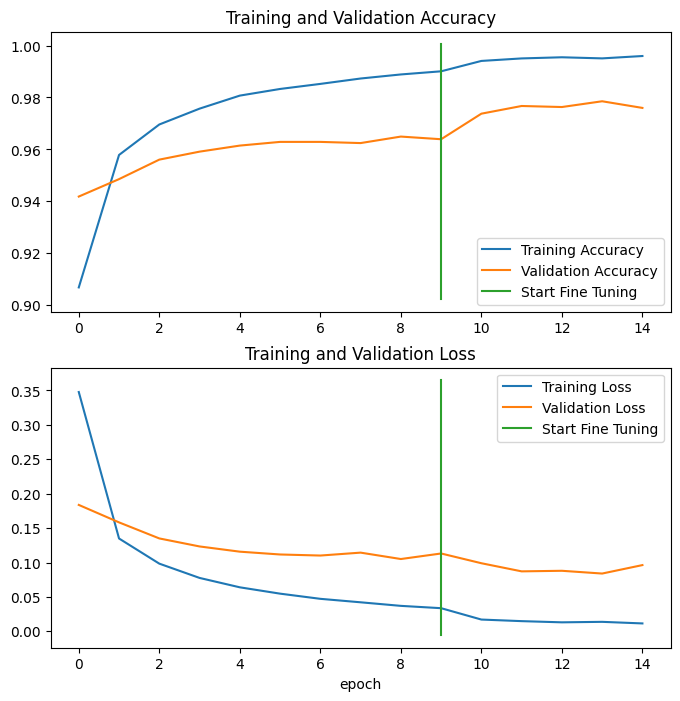

In [56]:
# Compare the historys of feature extraction model with fine-tuning model
compare_historys(original_history = mobv2_model_history, 
                 new_history = mobv2_fine_tuning_history,
                 initial_epochs = 10
                )

## 8. Fine-Tuned MobileNetV2 Model Evaluation

In [57]:
# Make predictions on the validation set
predictions = mobv2_model.predict(val_data)

# Convert predictions from probabilities to class labels
predicted_classes = predictions.argmax(axis=1)

# Get True Labels
# Initialize an empty list to store the true labels
true_labels_list = []

# Iterate over the val_data dataset and collect the labels (y)
for images, labels in val_data:
    # 'labels' is a batch of one-hot encoded labels.
    # We append the batch to our list.
    true_labels_list.append(labels.numpy())

# Concatenate all label batches into a single numpy array
true_labels_categorical = np.concatenate(true_labels_list, axis=0)

# Convert the one-hot encoded labels to integer class indices
true_classes = np.argmax(true_labels_categorical, axis=1)

# Get class labels
class_labels = val_data.class_names

# Generate classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

print(report)

550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       504
                                 Apple___Black_rot       1.00      0.99      1.00       497
                          Apple___Cedar_apple_rust       0.99      1.00      0.99       440
                                   Apple___healthy       0.98      0.99      0.99       502
                               Blueberry___healthy       0.99      1.00      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       421
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.95      0.95       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northe

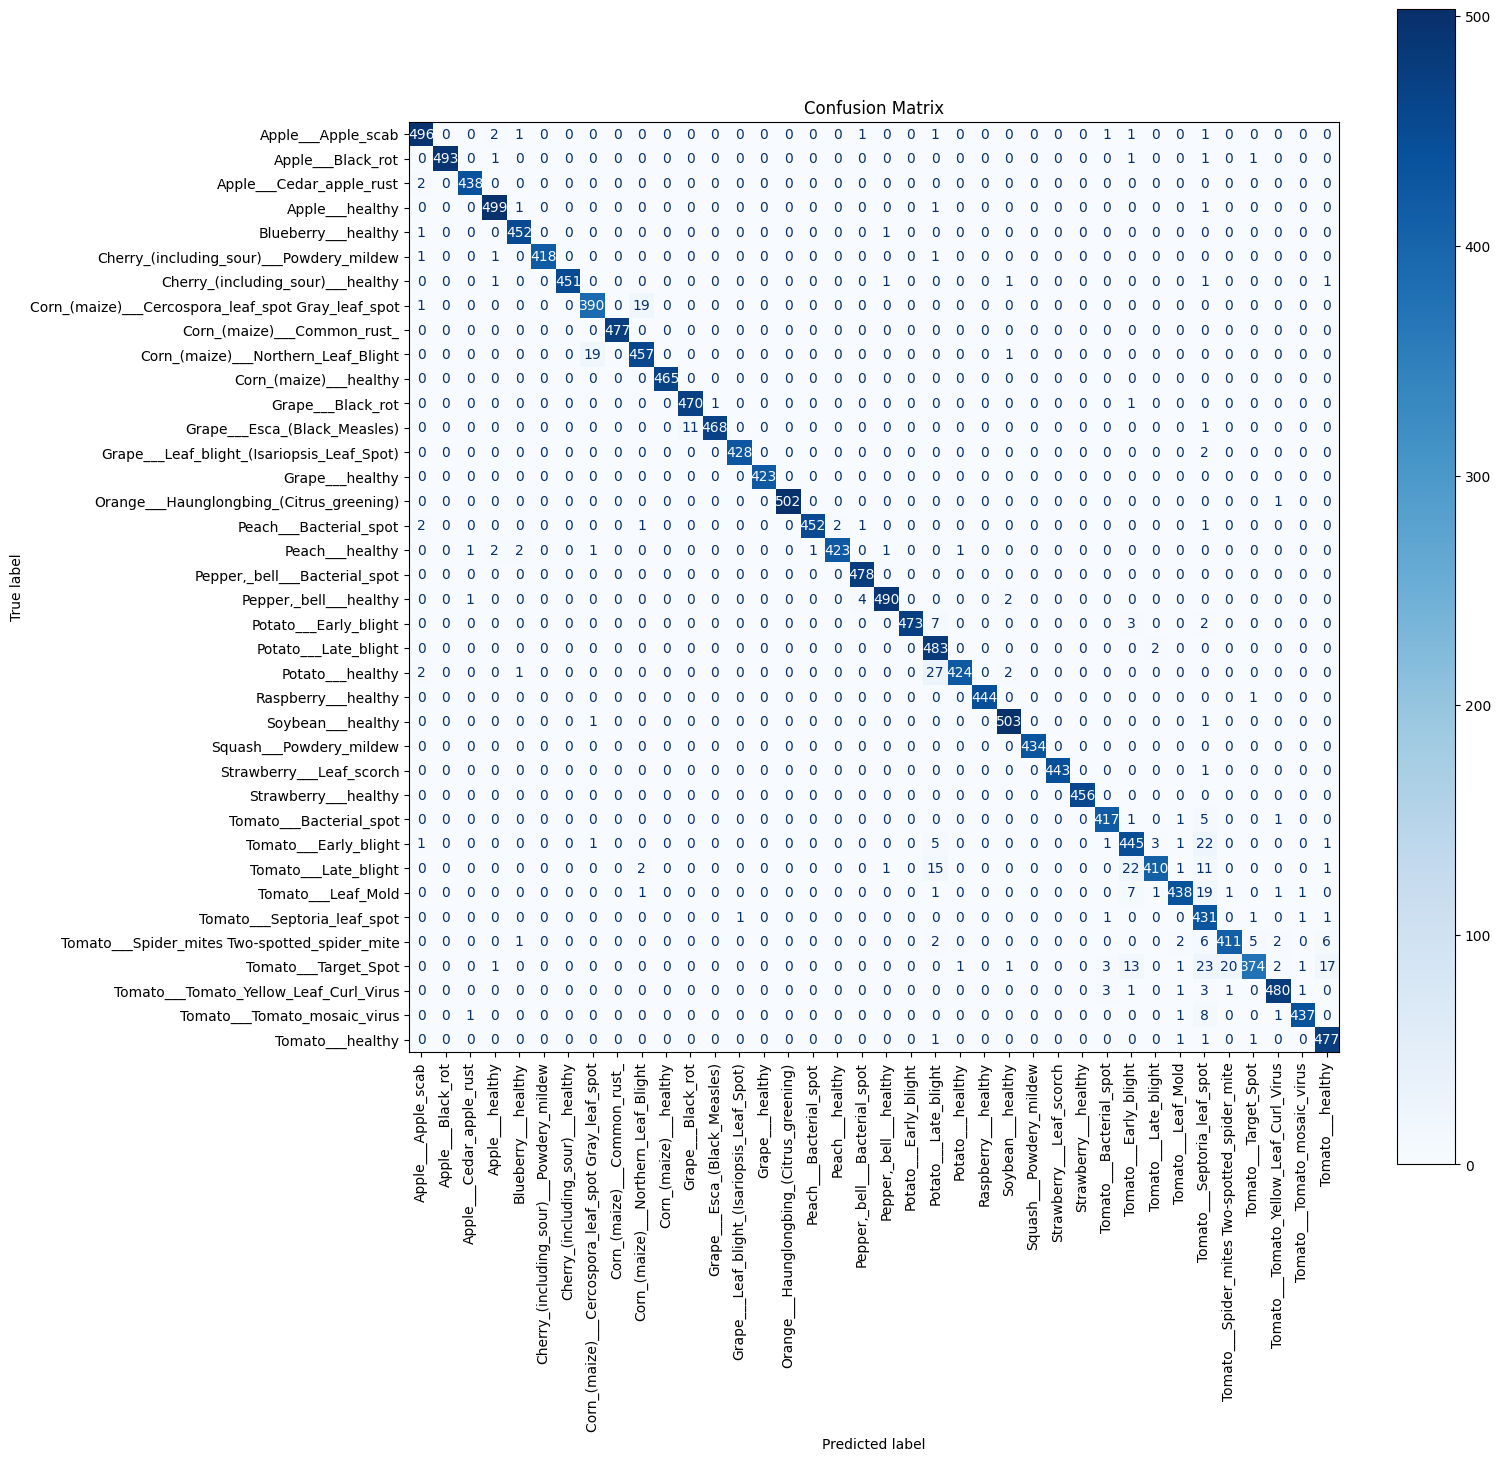

In [58]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, 
                              display_labels = class_labels
                             )

fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(cmap = "Blues", ax=ax)

plt.xticks(rotation = 90)
plt.title('Confusion Matrix')
plt.show()

## 9. Fine-Tuned MobileNetV2 Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


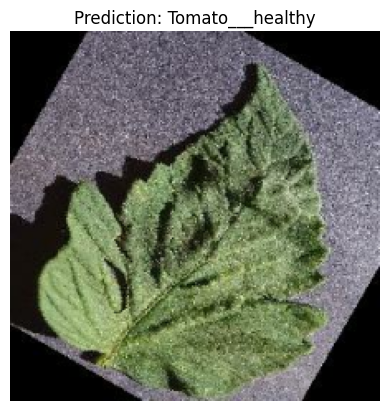

In [59]:
image_path = test_dir + "TomatoHealthy3.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


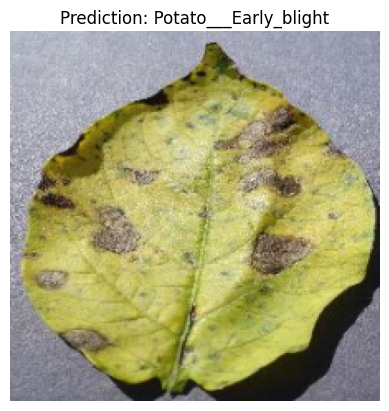

In [61]:
image_path = test_dir + "PotatoEarlyBlight4.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


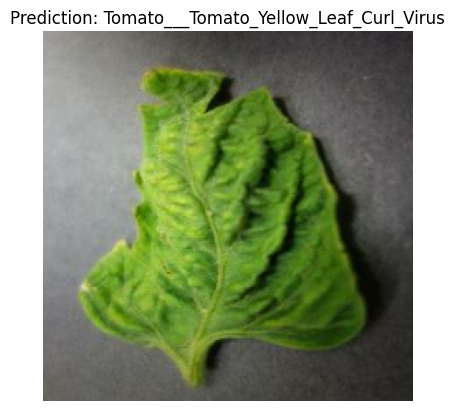

In [63]:
image_path = test_dir + "TomatoYellowCurlVirus4.JPG"

make_predictions(model = mobv2_model, 
                 class_names = class_names, 
                 image_path = image_path
                )

## 10. Save Fine-Tuned MobileNetV2 Model

In [64]:
mobv2_model.save("MobileNetV2_Fine_Tuned_Model.keras")